# Experiment 1 — Sensitivity via Backward Perturbation Along a Trajectory

Assess uncertainty of DiT by measuring how much the **final image** changes when we perturb a mid-trajectory latent by moving **backward** (toward higher noise) and then denoising to completion.

**Protocol**
1. Generate one reference reverse trajectory from a fixed start seed; save latents at selected checkpoints.
2. From a checkpoint, add noise for $\Delta \in \{1,2,5\}$ steps *backward* along the diffusion trajectory (closed-form $q(x_{t+\Delta}\mid x_t)$).
3. Denoise back to $x_0$. **Perturbation seeds** and **denoising (step-noise) seeds** are controlled separately so the two stochasticities are not conflated.
4. Measure ensemble spread in CLIP / DINOv2 embeddings, pairwise LPIPS, and MSE on final latents; inspect images.

**Also included:** baseline — resume from the same checkpoints *without* re-noising, varying only denoising seeds (continue-from-checkpoint plot).

# 1. Setup

In [1]:
%cd ../

/home/sepuhopar/dev/SMILES-Project-27-Uncertainty-in-Diffusion


In [2]:
#!git clone https://github.com/facebookresearch/DiT.git
import DiT, os
os.chdir("DiT")

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
from tqdm.auto import tqdm
from torchvision.utils import make_grid, save_image

from diffusion import create_diffusion
from diffusers.models import AutoencoderKL
from download import find_model
from models import DiT_XL_2

torch.set_grad_enabled(False)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device={device}")
if device == "cpu":
    print("GPU not found. Using CPU instead.")

Multiple distributions found for package optimum. Picked distribution: optimum
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


device=cuda


# 2. Load DiT-XL/2

In [3]:
image_size = 256  #@param [256, 512]
vae_model = "stabilityai/sd-vae-ft-ema"  #@param ["stabilityai/sd-vae-ft-mse", "stabilityai/sd-vae-ft-ema"]
latent_size = int(image_size) // 8

model = DiT_XL_2(input_size=latent_size).to(device)
state_dict = find_model(f"DiT-XL-2-{image_size}x{image_size}.pt")
model.load_state_dict(state_dict)
model.eval()
vae = AutoencoderKL.from_pretrained(vae_model).to(device)
print("Model + VAE ready.")

/home/sepuhopar/miniconda3/envs/ldm/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Model + VAE ready.


# 3. Config

In [4]:
# ---- Sampling ----
cfg_scale = 4.0  #@param {type:"slider", min:1, max:10, step:0.1}
num_sampling_steps = 250  #@param {type:"slider", min:10, max:1000, step:1}
class_label = 207  #@param {type:"integer"}
traj_seed = 0  #@param {type:"integer"}  # fixed start for the reference trajectory

# Checkpoints along the reverse path (number of reverse steps already taken).
# 0 = initial noise; num_sampling_steps = fully denoised.
checkpoint_steps = (50, 100, 150, 200)  #@param {type:"raw"}

# Backward jumps (in spaced reverse steps)
deltas = (1, 2, 5)  #@param {type:"raw"}

# Ensemble sizes
K_pert = 8  #@param {type:"integer"}   # #perturbation realizations (vary pert seed)
K_denoise_baseline = 8  #@param {type:"integer"}  # baseline: resume w/o re-noise

# Seed separation
pert_seed_base = 1000  #@param {type:"integer"}
denoise_noise_seed = 12345  #@param {type:"integer"}  # shared reverse step-noise when isolating pert
baseline_denoise_seed_base = 2000  #@param {type:"integer"}

# Forward-jump noise type used when moving backward:
#   "gaussian"      — closed-form q(x_{t+Δ}|x_t) with N(0,I) noise
#   "gaussian_iter" — Δ successive one-step Markov forwards (same family, different realization path)
noise_type = "gaussian"  #@param ["gaussian", "gaussian_iter"]

RESULTS_DIR = Path("../results/exp1_backward_perturbation")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
SAMPLES_DIR = RESULTS_DIR / f"class_{class_label:04d}"
SAMPLES_DIR.mkdir(parents=True, exist_ok=True)

diffusion = create_diffusion(str(num_sampling_steps))
shape = (1, 4, latent_size, latent_size)
T = diffusion.num_timesteps
assert T == num_sampling_steps, (T, num_sampling_steps)
assert all(0 < s < T for s in checkpoint_steps), "checkpoints must be in (0, T)"
assert all(s - max(deltas) >= 0 for s in checkpoint_steps), (
    "each checkpoint must allow the largest backward jump"
)

print(f"class={class_label}, steps={T}, cfg={cfg_scale}")
print(f"checkpoints={checkpoint_steps}, deltas={deltas}, noise_type={noise_type}")
print(f"K_pert={K_pert}, K_denoise_baseline={K_denoise_baseline}")
print(f"results -> {RESULTS_DIR.resolve()}")

class=207, steps=250, cfg=4.0
checkpoints=(50, 100, 150, 200), deltas=(1, 2, 5), noise_type=gaussian
K_pert=8, K_denoise_baseline=8
results -> /home/sepuhopar/dev/SMILES-Project-27-Uncertainty-in-Diffusion/results/exp1_backward_perturbation


# 4. Diffusion helpers

Indexing convention:
- Reverse step index $s=0$: initial noise (input to the first reverse step).
- After $s$ reverse steps, latent `traj[s]` is the input for spaced timestep index $i = T-1-s$.
- Moving **backward** by $\Delta$ means jumping to a *noisier* latent and resuming from step $s-\Delta$.

In [5]:
def _extract(a, t, x_shape):
    """Gather diffusion schedule values for a batch of timesteps (numpy or tensor)."""
    if isinstance(a, np.ndarray):
        res = torch.from_numpy(a).to(device=t.device)[t].float()
    else:
        res = torch.as_tensor(a, device=t.device, dtype=torch.float32)[t]
    while len(res.shape) < len(x_shape):
        res = res[..., None]
    return res + torch.zeros(x_shape, device=t.device)


def spaced_index_at_step(s):
    """Spaced diffusion index used as model-t when the latent is traj[s] (s < T)."""
    return T - 1 - s


def decode_latents(latents):
    return vae.decode(latents / 0.18215).sample


def save_uint8_image(tensor_chw, path):
    x = torch.clamp(127.5 * tensor_chw + 128.0, 0, 255)
    x = x.permute(1, 2, 0).to("cpu", dtype=torch.uint8).numpy()
    Image.fromarray(x).save(path)


def p_sample_with_noise(diffusion, model_fn, x, t, step_noise, model_kwargs):
    """Like diffusion.p_sample, but uses provided step_noise instead of randn."""
    out = diffusion.p_mean_variance(
        model_fn, x, t, clip_denoised=False, model_kwargs=model_kwargs
    )
    nonzero_mask = (t != 0).float().view(-1, *([1] * (len(x.shape) - 1)))
    sample = out["mean"] + nonzero_mask * torch.exp(0.5 * out["log_variance"]) * step_noise
    return {"sample": sample, "pred_xstart": out["pred_xstart"]}


def precompute_step_noise(noise_seed, start_step=0):
    """Per reverse-step ε for CFG batch (2, C, H, W), indexed by reverse step_i."""
    g = torch.Generator(device=device)
    g.manual_seed(int(noise_seed))
    noises = []
    for _ in range(T):
        noises.append(torch.randn(2, 4, latent_size, latent_size, generator=g, device=device))
    return noises[start_step:]  # align so noises[0] is used at reverse step start_step


def cfg_kwargs(class_label):
    y = torch.tensor([class_label, 1000], device=device)
    return dict(y=y, cfg_scale=cfg_scale)


def generate_trajectory(class_label, seed, save_steps):
    """Run one full reverse path; return dict step -> latent (1,C,H,W) on CPU.

    traj[0] = initial noise; traj[T] = final latent.
    """
    save_set = set(save_steps) | {0, T}
    torch.manual_seed(seed)
    z = torch.randn(*shape, device=device)
    img = torch.cat([z, z], dim=0)
    model_kwargs = cfg_kwargs(class_label)

    traj = {}
    if 0 in save_set:
        traj[0] = img[:1].detach().cpu()

    indices = list(range(T))[::-1]
    for step_i, i in enumerate(tqdm(indices, desc="reference trajectory", leave=False)):
        t = torch.tensor([i, i], device=device)
        out = diffusion.p_sample(
            model.forward_with_cfg,
            img,
            t,
            clip_denoised=False,
            model_kwargs=model_kwargs,
        )
        img = out["sample"]
        s = step_i + 1  # steps completed
        if s in save_set:
            traj[s] = img[:1].detach().cpu()

    return traj

def forward_jump(x, t_from, t_to, noise):
    """Closed-form q(x_{t_to} | x_{t_from}) for t_to > t_from (more noise).

    x_to = sqrt(ᾱ_to / ᾱ_from) x_from + sqrt(1 - ᾱ_to/ᾱ_from) ε
    """
    assert int(t_to) > int(t_from)
    t_from_b = torch.tensor([int(t_from)], device=x.device)
    t_to_b = torch.tensor([int(t_to)], device=x.device)
    a_from = _extract(diffusion.alphas_cumprod, t_from_b, x.shape)
    a_to = _extract(diffusion.alphas_cumprod, t_to_b, x.shape)
    ratio = (a_to / a_from).clamp(min=1e-12)
    return torch.sqrt(ratio) * x + torch.sqrt((1.0 - ratio).clamp(min=0.0)) * noise


def forward_jump_iterative(x, t_from, t_to, generator):
    """Apply one-step Markov forwards from t_from to t_to-1 → x at t_to."""
    x_cur = x
    for t in range(int(t_from), int(t_to)):
        # one-step: q(x_{t+1} | x_t) using closed form with Δt=1 in spaced index
        eps = torch.randn(x_cur.shape, generator=generator, device=x_cur.device)
        x_cur = forward_jump(x_cur, t, t + 1, eps)
    return x_cur


def perturb_backward(x_s, step_s, delta, pert_seed, noise_type="gaussian"):
    """Move latent at reverse-step step_s backward by delta steps.

    Returns perturbed latent (on device) and the resume reverse-step index.
    """
    resume_s = step_s - delta
    assert resume_s >= 0
    t_from = spaced_index_at_step(step_s)
    t_to = spaced_index_at_step(resume_s)
    assert t_to == t_from + delta

    x = x_s.to(device)
    g = torch.Generator(device=device)
    g.manual_seed(int(pert_seed))

    if noise_type == "gaussian":
        eps = torch.randn(x.shape, generator=g, device=device)
        x_pert = forward_jump(x, t_from, t_to, eps)
    elif noise_type == "gaussian_iter":
        x_pert = forward_jump_iterative(x, t_from, t_to, g)
    else:
        raise ValueError(f"Unknown noise_type={noise_type}")

    return x_pert, resume_s

def denoise_from(x_start, start_step, class_label, step_noises):
    """Continue reverse diffusion from reverse-step start_step to the end.

    step_noises[k] is used at reverse step start_step + k (CFG-shaped).
    Returns final latent (1,C,H,W) on CPU.
    """
    img = torch.cat([x_start, x_start], dim=0)
    model_kwargs = cfg_kwargs(class_label)
    indices = list(range(T))[::-1]

    for k, step_i in enumerate(range(start_step, T)):
        i = indices[step_i]
        t = torch.tensor([i, i], device=device)
        out = p_sample_with_noise(
            diffusion,
            model.forward_with_cfg,
            img,
            t,
            step_noises[k],
            model_kwargs,
        )
        img = out["sample"]

    return img[:1].detach().cpu()


print("Diffusion helpers ready.")

Diffusion helpers ready.


# 5. Feature / spread metric helpers (CLIP, DINOv2, LPIPS, latent MSE)

In [6]:
import open_clip
import lpips
from transformers import AutoImageProcessor, AutoModel


# ---- CLIP (OpenCLIP ViT-B/32) ----
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="openai"
)
clip_model = clip_model.to(device).eval()

# ---- DINOv2 ----
dino_name = "facebook/dinov2-small"
dino_processor = AutoImageProcessor.from_pretrained(dino_name)
dino_model = AutoModel.from_pretrained(dino_name).to(device).eval()

# ---- LPIPS ----
lpips_fn = lpips.LPIPS(net="alex").to(device).eval()


def _images_to_pil_list(imgs_bchw):
    """imgs in [-1,1] -> list of PIL RGB."""
    x = torch.clamp(imgs_bchw * 0.5 + 0.5, 0, 1)
    out = []
    for i in range(x.shape[0]):
        arr = (x[i].permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)
        out.append(Image.fromarray(arr))
    return out


@torch.no_grad()
def embed_clip(imgs_bchw):
    pils = _images_to_pil_list(imgs_bchw)
    tensors = torch.stack([clip_preprocess(p) for p in pils]).to(device)
    feats = clip_model.encode_image(tensors)
    return F.normalize(feats.float(), dim=-1).cpu()


@torch.no_grad()
def embed_dino(imgs_bchw):
    pils = _images_to_pil_list(imgs_bchw)
    inputs = dino_processor(images=pils, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    out = dino_model(**inputs)
    # CLS token
    feats = out.last_hidden_state[:, 0]
    return F.normalize(feats.float(), dim=-1).cpu()


def feature_spread(feats):
    """feats: (K, D) L2-normalized. Return mean pairwise cosine distance & trace variance."""
    K = feats.shape[0]
    # variance of features (unnormalized spread proxy)
    var = feats.var(dim=0, unbiased=False).sum().item()
    # mean pairwise cosine distance = 1 - cos
    sim = feats @ feats.T
    iu = torch.triu_indices(K, K, offset=1)
    mean_cos_dist = (1.0 - sim[iu[0], iu[1]]).mean().item() if K > 1 else 0.0
    return {"feat_var": var, "mean_cos_dist": mean_cos_dist}


@torch.no_grad()
def pairwise_lpips(imgs_bchw):
    """Mean pairwise LPIPS over ensemble (imgs in [-1,1])."""
    K = imgs_bchw.shape[0]
    if K < 2:
        return 0.0
    x = imgs_bchw.to(device)
    dists = []
    for i in range(K):
        for j in range(i + 1, K):
            d = lpips_fn(x[i : i + 1], x[j : j + 1])
            dists.append(float(d.item()))
    return float(np.mean(dists))


def latent_mse_spread(latents_kchw):
    """Mean pairwise MSE and per-dim variance sum on latents (K,C,H,W)."""
    K = latents_kchw.shape[0]
    flat = latents_kchw.reshape(K, -1)
    var = flat.var(dim=0, unbiased=False).sum().item()
    if K < 2:
        return {"latent_var": var, "mean_pairwise_mse": 0.0}
    mses = []
    for i in range(K):
        for j in range(i + 1, K):
            mses.append(F.mse_loss(flat[i], flat[j]).item())
    return {"latent_var": var, "mean_pairwise_mse": float(np.mean(mses))}


def compute_ensemble_metrics(final_latents):
    """final_latents: (K,C,H,W) CPU. Decode once, return metric dict + images."""
    with torch.no_grad():
        imgs = decode_latents(final_latents.to(device)).cpu()
    clip_f = embed_clip(imgs)
    dino_f = embed_dino(imgs)
    metrics = {}
    metrics.update({f"clip_{k}": v for k, v in feature_spread(clip_f).items()})
    metrics.update({f"dino_{k}": v for k, v in feature_spread(dino_f).items()})
    metrics["lpips_mean"] = pairwise_lpips(imgs)
    metrics.update(latent_mse_spread(final_latents))
    return metrics, imgs


print("Metric helpers ready (CLIP / DINOv2 / LPIPS).")

open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/home/sepuhopar/miniconda3/envs/ldm/lib/python3.11/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/547 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/home/sepuhopar/miniconda3/envs/ldm/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/sepuhopar/miniconda3/envs/ldm/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/sepuhopar/miniconda3/envs/ldm/lib/python3.11/site-packages/lpips/weights/v0.1/alex.pth
Metric helpers ready (CLIP / DINOv2 / LPIPS).


# 6. Generate & save the reference trajectory

reference trajectory:   0%|          | 0/250 [00:00<?, ?it/s]

Saved trajectory -> ../results/exp1_backward_perturbation/class_0207/traj_seed0.pt (keys=[0, 50, 100, 150, 200, 250])


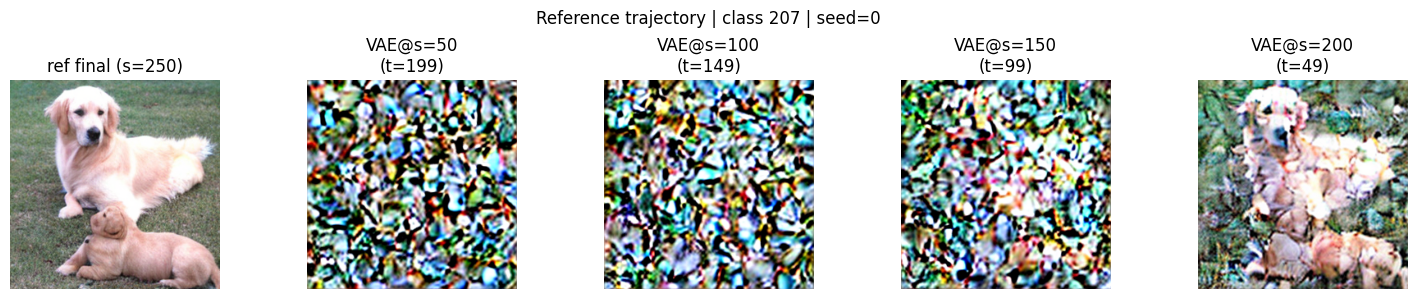

In [7]:
traj_path = SAMPLES_DIR / f"traj_seed{traj_seed}.pt"
if traj_path.exists():
    payload = torch.load(traj_path, map_location="cpu", weights_only=False)
    traj = {int(k): v for k, v in payload["traj"].items()}
    print(f"Loaded trajectory from {traj_path} (keys={sorted(traj)})")
else:
    traj = generate_trajectory(
        class_label,
        traj_seed,
        save_steps=list(checkpoint_steps),
    )
    torch.save(
        {
            "traj": traj,
            "class_label": class_label,
            "traj_seed": traj_seed,
            "num_sampling_steps": T,
            "cfg_scale": cfg_scale,
        },
        traj_path,
    )
    print(f"Saved trajectory -> {traj_path} (keys={sorted(traj)})")

# Decode reference final + checkpoint x0 previews (VAE decode of latent, not pred_xstart)
ref_final = traj[T]
with torch.no_grad():
    ref_img = decode_latents(ref_final.to(device))[0].cpu()
save_uint8_image(ref_img, SAMPLES_DIR / "reference_final.png")

fig, axes = plt.subplots(1, 1 + len(checkpoint_steps), figsize=(3 * (1 + len(checkpoint_steps)), 3))
axes = np.atleast_1d(axes)
axes[0].imshow((ref_img.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1))
axes[0].set_title(f"ref final (s={T})")
axes[0].axis("off")
for ax, s in zip(axes[1:], checkpoint_steps):
    with torch.no_grad():
        preview = decode_latents(traj[s].to(device))[0].cpu()
    ax.imshow((preview.permute(1, 2, 0).numpy() * 0.5 + 0.5).clip(0, 1))
    ax.set_title(f"VAE@s={s}\n(t={spaced_index_at_step(s)})")
    ax.axis("off")
fig.suptitle(f"Reference trajectory | class {class_label} | seed={traj_seed}")
plt.tight_layout()
plt.show()

# 7. Baseline — resume from checkpoints (no re-noise)

From each saved latent, continue generation with **different denoising step-noise seeds** (perturbation = identity).  
This isolates the effect of reverse-process stochasticity when starting from the same mid-trajectory point.

baseline s=50:   0%|          | 0/8 [00:00<?, ?it/s]

[baseline] s=50: clip_feat_var=0.1094, clip_mean_cos_dist=0.1250, dino_feat_var=0.3357, dino_mean_cos_dist=0.3837, lpips_mean=0.7006, latent_var=2183.3813, mean_pairwise_mse=1.2184


baseline s=100:   0%|          | 0/8 [00:00<?, ?it/s]

[baseline] s=100: clip_feat_var=0.0932, clip_mean_cos_dist=0.1066, dino_feat_var=0.3024, dino_mean_cos_dist=0.3457, lpips_mean=0.5406, latent_var=1639.9819, mean_pairwise_mse=0.9152


baseline s=150:   0%|          | 0/8 [00:00<?, ?it/s]

[baseline] s=150: clip_feat_var=0.0978, clip_mean_cos_dist=0.1118, dino_feat_var=0.2370, dino_mean_cos_dist=0.2708, lpips_mean=0.3652, latent_var=1047.7556, mean_pairwise_mse=0.5847


baseline s=200:   0%|          | 0/8 [00:00<?, ?it/s]

[baseline] s=200: clip_feat_var=0.0237, clip_mean_cos_dist=0.0271, dino_feat_var=0.0911, dino_mean_cos_dist=0.1041, lpips_mean=0.1807, latent_var=464.5891, mean_pairwise_mse=0.2593


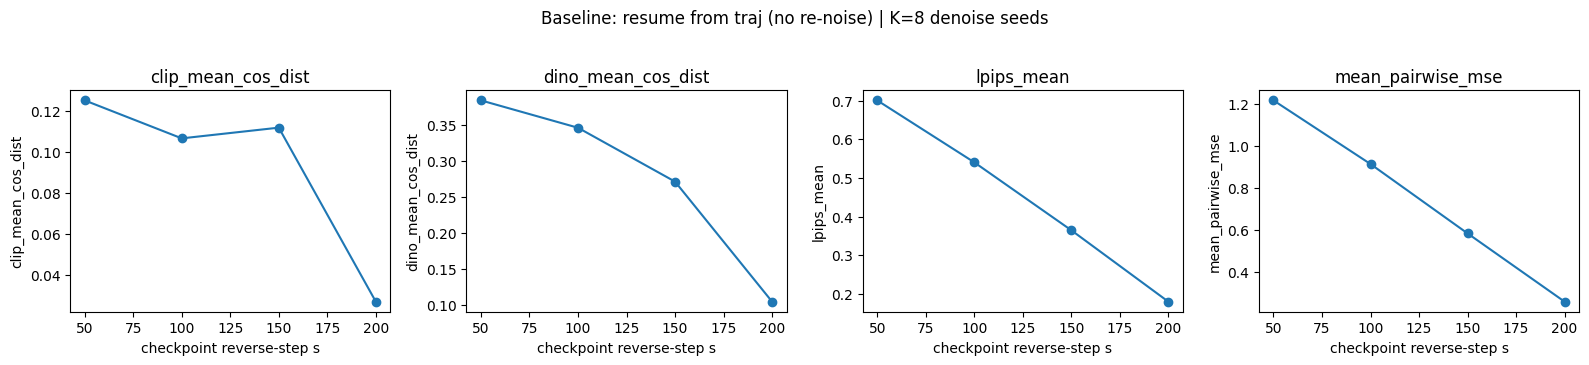

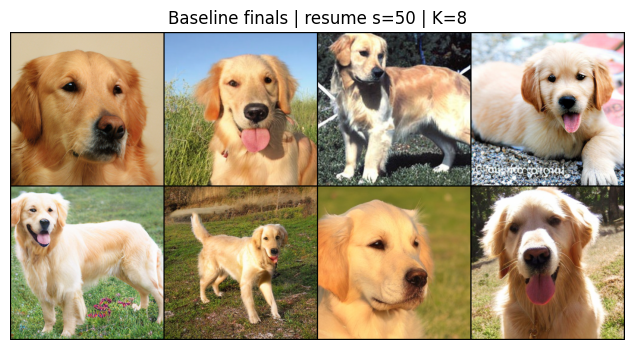

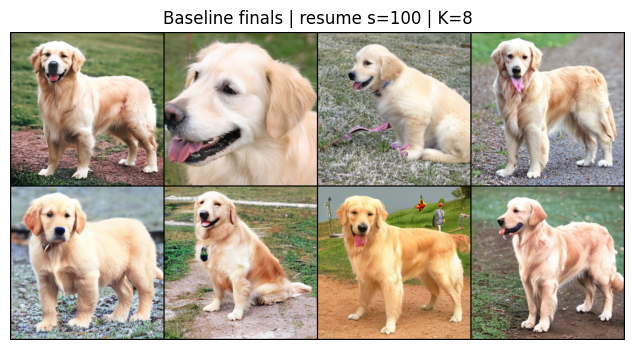

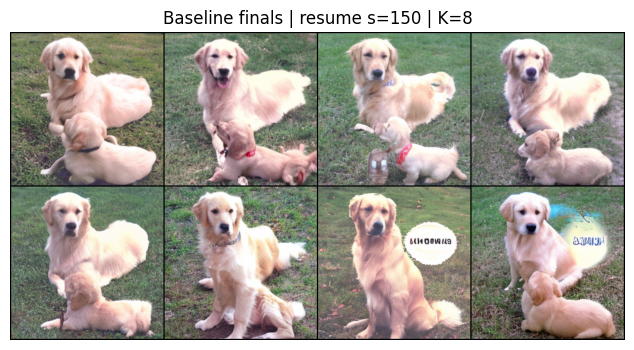

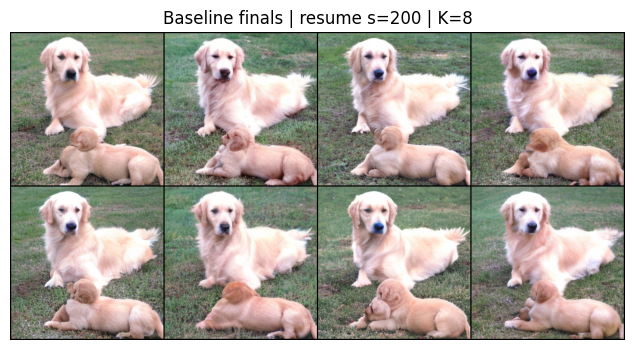

In [8]:
baseline_results = {}  # step -> {metrics, images, latents}

for s in checkpoint_steps:
    finals = []
    x_s = traj[s].to(device)
    for k in tqdm(range(K_denoise_baseline), desc=f"baseline s={s}", leave=False):
        seed = baseline_denoise_seed_base + k
        step_noises = precompute_step_noise(seed, start_step=s)
        finals.append(denoise_from(x_s, s, class_label, step_noises))
    finals = torch.cat(finals, dim=0)  # (K,C,H,W)
    metrics, imgs = compute_ensemble_metrics(finals)
    baseline_results[s] = {"metrics": metrics, "images": imgs, "latents": finals}
    print(f"[baseline] s={s}: " + ", ".join(f"{k}={v:.4f}" for k, v in metrics.items()))

# Plot spread vs checkpoint
metric_keys = [
    "clip_mean_cos_dist",
    "dino_mean_cos_dist",
    "lpips_mean",
    "mean_pairwise_mse",
]
fig, axes = plt.subplots(1, len(metric_keys), figsize=(4 * len(metric_keys), 3.5))
xs = list(checkpoint_steps)
for ax, key in zip(axes, metric_keys):
    ys = [baseline_results[s]["metrics"][key] for s in xs]
    ax.plot(xs, ys, marker="o")
    ax.set_xlabel("checkpoint reverse-step s")
    ax.set_ylabel(key)
    ax.set_title(key)
fig.suptitle(
    f"Baseline: resume from traj (no re-noise) | K={K_denoise_baseline} denoise seeds",
    y=1.03,
)
plt.tight_layout()
plt.show()

# Image grids
for s in checkpoint_steps:
    grid = make_grid(baseline_results[s]["images"], nrow=4, normalize=True, value_range=(-1, 1))
    plt.figure(figsize=(10, 4))
    plt.imshow(grid.permute(1, 2, 0).numpy())
    plt.axis("off")
    plt.title(f"Baseline finals | resume s={s} | K={K_denoise_baseline}")
    plt.show()

# 8. Experiment 1 — backward perturbation ($\Delta \in \{1,2,5\}$)

For each checkpoint $s$ and jump $\Delta$:
- draw $K_{\mathrm{pert}}$ perturbation noises (`pert_seed_base + k`)
- jump to reverse-step $s-\Delta$ via `noise_type`
- denoise to the end with a **shared** reverse step-noise seed (`denoise_noise_seed`)

Spread across the ensemble is then attributable primarily to the backward perturbation.

In [9]:
exp1_results = {}  # (s, delta) -> {metrics, images, latents}

for s in checkpoint_steps:
    x_s = traj[s]
    for delta in deltas:
        finals = []
        resume_s = s - delta
        # Shared denoise noise for all members, aligned to resume_s
        shared_noises = precompute_step_noise(denoise_noise_seed, start_step=resume_s)

        for k in tqdm(
            range(K_pert), desc=f"exp1 s={s} Δ={delta}", leave=False
        ):
            pert_seed = pert_seed_base + k
            x_pert, resume = perturb_backward(
                x_s, s, delta, pert_seed, noise_type=noise_type
            )
            assert resume == resume_s
            finals.append(denoise_from(x_pert, resume_s, class_label, shared_noises))

        finals = torch.cat(finals, dim=0)
        metrics, imgs = compute_ensemble_metrics(finals)
        exp1_results[(s, delta)] = {
            "metrics": metrics,
            "images": imgs,
            "latents": finals,
        }
        print(
            f"[exp1] s={s}, Δ={delta}, resume={resume_s}: "
            + ", ".join(f"{k}={v:.4f}" for k, v in metrics.items())
        )

# Save metrics JSON (no tensors)
metrics_out = {
    "config": {
        "class_label": class_label,
        "traj_seed": traj_seed,
        "checkpoint_steps": list(checkpoint_steps),
        "deltas": list(deltas),
        "K_pert": K_pert,
        "K_denoise_baseline": K_denoise_baseline,
        "noise_type": noise_type,
        "pert_seed_base": pert_seed_base,
        "denoise_noise_seed": denoise_noise_seed,
        "cfg_scale": cfg_scale,
        "num_sampling_steps": T,
    },
    "baseline": {str(s): baseline_results[s]["metrics"] for s in checkpoint_steps},
    "exp1": {
        f"s{s}_d{delta}": exp1_results[(s, delta)]["metrics"]
        for s in checkpoint_steps
        for delta in deltas
    },
}
metrics_path = SAMPLES_DIR / f"metrics_{noise_type}.json"
with open(metrics_path, "w") as f:
    json.dump(metrics_out, f, indent=2)
print(f"Wrote {metrics_path}")

exp1 s=50 Δ=1:   0%|          | 0/8 [00:00<?, ?it/s]

[exp1] s=50, Δ=1, resume=49: clip_feat_var=0.0366, clip_mean_cos_dist=0.0418, dino_feat_var=0.0924, dino_mean_cos_dist=0.1056, lpips_mean=0.2489, latent_var=610.4969, mean_pairwise_mse=0.3407


exp1 s=50 Δ=2:   0%|          | 0/8 [00:00<?, ?it/s]

[exp1] s=50, Δ=2, resume=48: clip_feat_var=0.0387, clip_mean_cos_dist=0.0442, dino_feat_var=0.0653, dino_mean_cos_dist=0.0746, lpips_mean=0.2055, latent_var=453.1602, mean_pairwise_mse=0.2529


exp1 s=50 Δ=5:   0%|          | 0/8 [00:00<?, ?it/s]

...

[exp1] s=200, Δ=1, resume=199: clip_feat_var=0.0078, clip_mean_cos_dist=0.0089, dino_feat_var=0.0211, dino_mean_cos_dist=0.0241, lpips_mean=0.0316, latent_var=22.7029, mean_pairwise_mse=0.0127


exp1 s=200 Δ=2:   0%|          | 0/8 [00:00<?, ?it/s]

[exp1] s=200, Δ=2, resume=198: clip_feat_var=0.0098, clip_mean_cos_dist=0.0112, dino_feat_var=0.0306, dino_mean_cos_dist=0.0350, lpips_mean=0.0493, latent_var=42.2710, mean_pairwise_mse=0.0236


exp1 s=200 Δ=5:   0%|          | 0/8 [00:00<?, ?it/s]

[exp1] s=200, Δ=5, resume=195: clip_feat_var=0.0136, clip_mean_cos_dist=0.0155, dino_feat_var=0.0531, dino_mean_cos_dist=0.0607, lpips_mean=0.0821, latent_var=85.0735, mean_pairwise_mse=0.0475
Wrote ../results/exp1_backward_perturbation/class_0207/metrics_gaussian.json


# 9. Plots — spread vs checkpoint and $\Delta$

Saved ../results/exp1_backward_perturbation/class_0207/spread_vs_checkpoint_gaussian.png


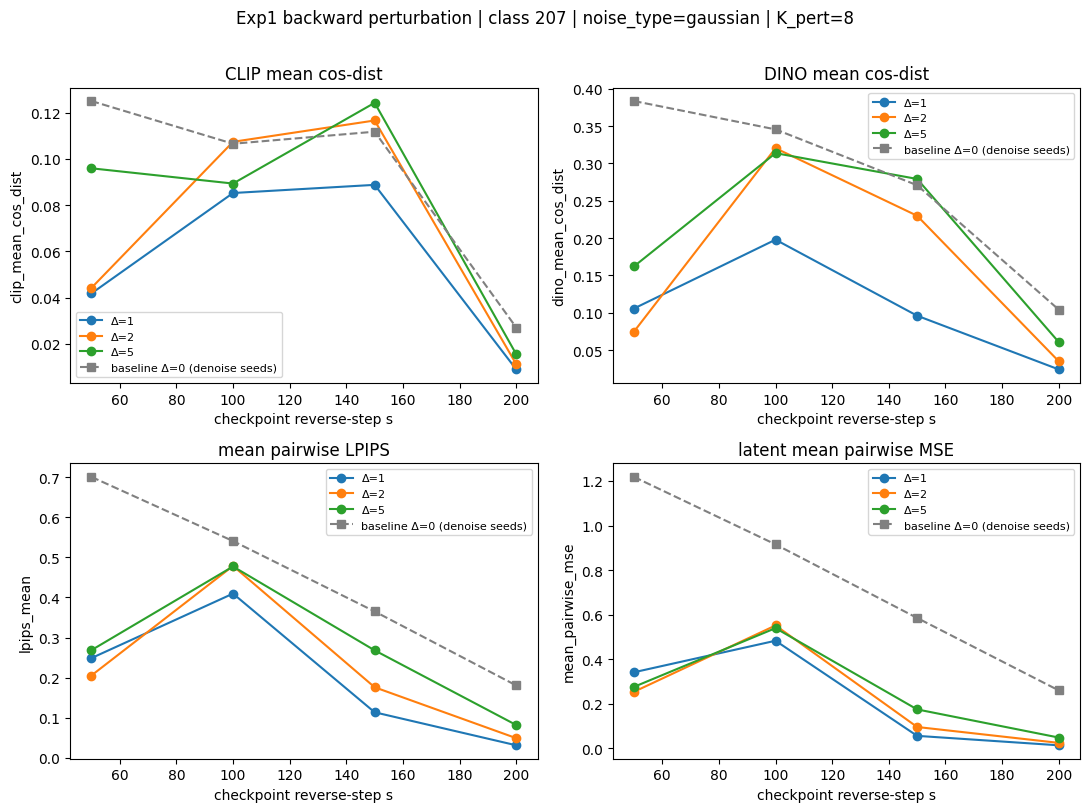

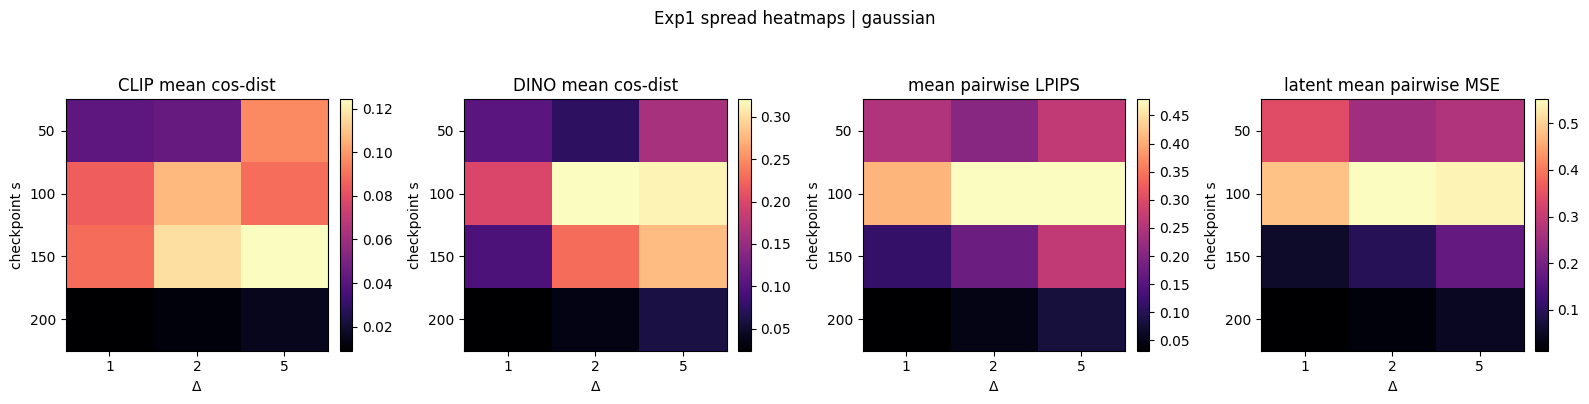

In [10]:
plot_keys = [
    ("clip_mean_cos_dist", "CLIP mean cos-dist"),
    ("dino_mean_cos_dist", "DINO mean cos-dist"),
    ("lpips_mean", "mean pairwise LPIPS"),
    ("mean_pairwise_mse", "latent mean pairwise MSE"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.ravel()
for ax, (key, title) in zip(axes, plot_keys):
    for delta in deltas:
        ys = [exp1_results[(s, delta)]["metrics"][key] for s in checkpoint_steps]
        ax.plot(list(checkpoint_steps), ys, marker="o", label=f"Δ={delta}")
    # overlay baseline (Δ=0, denoise-seed ensemble)
    ys_b = [baseline_results[s]["metrics"][key] for s in checkpoint_steps]
    ax.plot(
        list(checkpoint_steps),
        ys_b,
        marker="s",
        linestyle="--",
        color="gray",
        label="baseline Δ=0 (denoise seeds)",
    )
    ax.set_xlabel("checkpoint reverse-step s")
    ax.set_ylabel(key)
    ax.set_title(title)
    ax.legend(fontsize=8)
fig.suptitle(
    f"Exp1 backward perturbation | class {class_label} | noise_type={noise_type} | K_pert={K_pert}",
    y=1.01,
)
plt.tight_layout()
fig_path = SAMPLES_DIR / f"spread_vs_checkpoint_{noise_type}.png"
fig.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Saved {fig_path}")
plt.show()

# Heatmap: rows=checkpoint, cols=delta
fig, axes = plt.subplots(1, len(plot_keys), figsize=(4 * len(plot_keys), 3.8))
for ax, (key, title) in zip(axes, plot_keys):
    mat = np.array(
        [
            [exp1_results[(s, d)]["metrics"][key] for d in deltas]
            for s in checkpoint_steps
        ]
    )
    im = ax.imshow(mat, aspect="auto", cmap="magma")
    ax.set_xticks(range(len(deltas)))
    ax.set_xticklabels([str(d) for d in deltas])
    ax.set_yticks(range(len(checkpoint_steps)))
    ax.set_yticklabels([str(s) for s in checkpoint_steps])
    ax.set_xlabel("Δ")
    ax.set_ylabel("checkpoint s")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle(f"Exp1 spread heatmaps | {noise_type}", y=1.05)
plt.tight_layout()
plt.show()

# 10. Visual inspection — ensemble grids

Reference image on the left of each row title; ensemble members for selected $(s, \Delta)$.

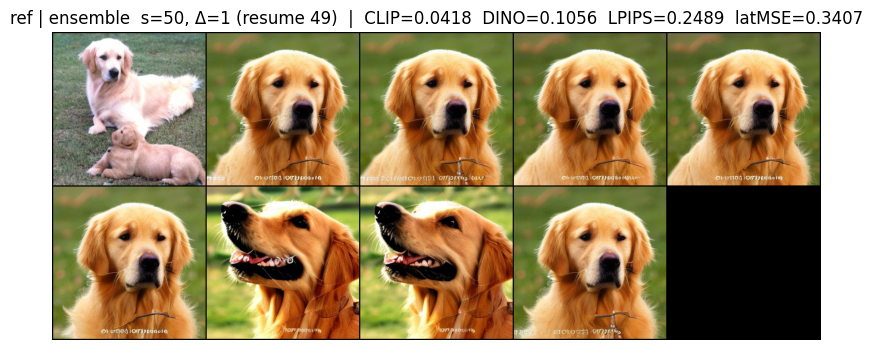

Saved ../results/exp1_backward_perturbation/class_0207/grid_s50_d1_gaussian.png


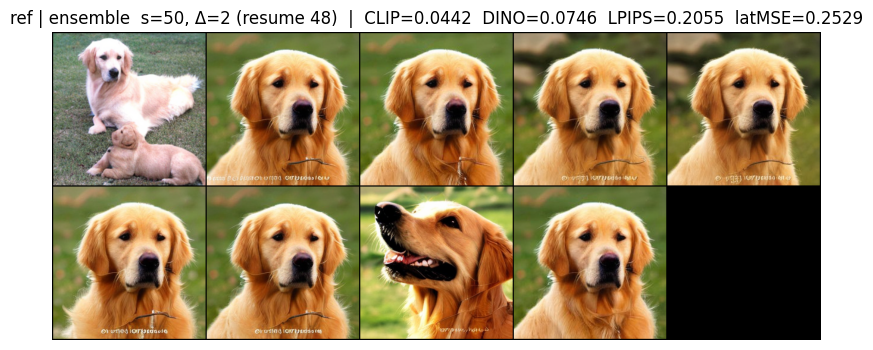

Saved ../results/exp1_backward_perturbation/class_0207/grid_s50_d2_gaussian.png


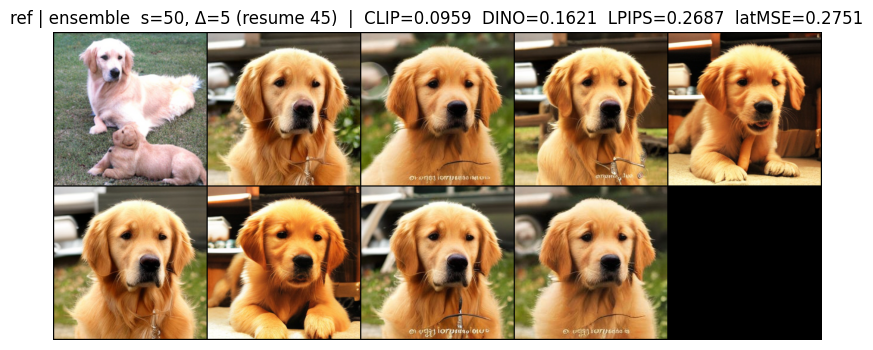

Saved ../results/exp1_backward_perturbation/class_0207/grid_s50_d5_gaussian.png


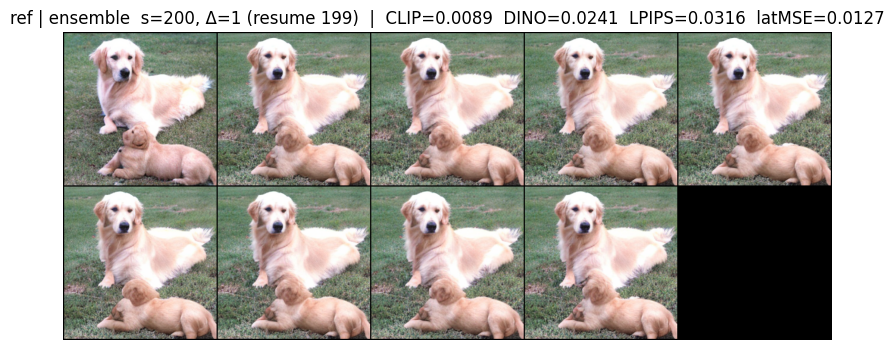

Saved ../results/exp1_backward_perturbation/class_0207/grid_s200_d1_gaussian.png


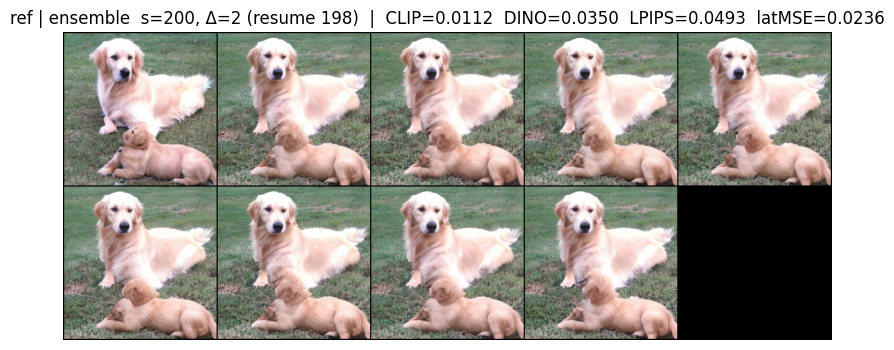

Saved ../results/exp1_backward_perturbation/class_0207/grid_s200_d2_gaussian.png


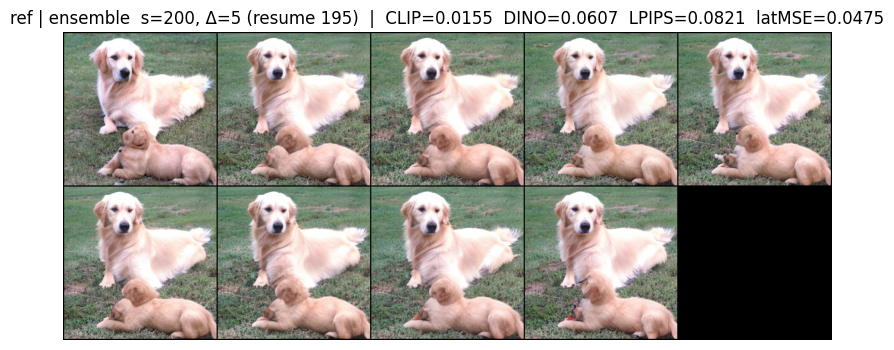

Saved ../results/exp1_backward_perturbation/class_0207/grid_s200_d5_gaussian.png


In [11]:
# Show a manageable subset: first/last checkpoint × all deltas
show_steps = (checkpoint_steps[0], checkpoint_steps[-1])

for s in show_steps:
    for delta in deltas:
        imgs = exp1_results[(s, delta)]["images"]
        # prepend reference for comparison
        panel = torch.cat([ref_img.unsqueeze(0), imgs], dim=0)
        grid = make_grid(panel, nrow=min(5, panel.shape[0]), normalize=True, value_range=(-1, 1))
        plt.figure(figsize=(12, 4))
        plt.imshow(grid.permute(1, 2, 0).numpy())
        plt.axis("off")
        m = exp1_results[(s, delta)]["metrics"]
        plt.title(
            f"ref | ensemble  s={s}, Δ={delta} (resume {s - delta})  |  "
            f"CLIP={m['clip_mean_cos_dist']:.4f}  DINO={m['dino_mean_cos_dist']:.4f}  "
            f"LPIPS={m['lpips_mean']:.4f}  latMSE={m['mean_pairwise_mse']:.4f}"
        )
        out_path = SAMPLES_DIR / f"grid_s{s}_d{delta}_{noise_type}.png"
        plt.savefig(out_path, dpi=140, bbox_inches="tight")
        plt.show()
        print(f"Saved {out_path}")

# 11. Optional — swap noise type and re-run §8–10

Set `noise_type = "gaussian_iter"` in the config cell (or below) and re-execute from §8 to compare closed-form vs iterative forward noising with the **same** fixed denoising seed. Metrics are written to a separate JSON keyed by `noise_type`.

In [ ]:
# Uncomment to compare the other forward-noise realization without editing the config cell:
# noise_type = "gaussian_iter"
print(f"Current noise_type={noise_type}")
print("Re-run cells §8–10 after changing noise_type to collect a second curve.")